In [6]:
#Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [7]:
#Loading data. (renamed csv files for simplicity)
#May need to edit path to where datais stored on your computer.
test = 'churn_testing.csv'
train = 'churn_training.csv'
#------------------------------------------------------------
test_df = pd.read_csv(test)
train_df = pd.read_csv(train)
#Extras
original_df = train_df.copy()


In [8]:
train_df.dtypes

CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

In [9]:
#Displays number of data entries and columns in dataset
train_df.shape

(440833, 12)

In [14]:
#Checks for null values
train_df.isnull().sum()

Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [15]:
#Drops unimportant columns
train_df = train_df.drop(columns=['CustomerID'], errors='ignore')
train_df = train_df.dropna(subset=['Churn'])

In [16]:
#Drops unimportant columns
train_df = train_df.drop(columns=['CustomerID'], errors='ignore')
#Converts columns to be numerical in preperation of executing the random forest classification model
train_df['Churn'] = (
    train_df['Churn']
    .replace({'Churned': 1, 'Active': 0})
    .astype(float)
    .astype(int)
)
train_df['Gender'] = (train_df['Gender'] == 'Female').astype(int)


sub_mapping = {
    'Standard':0,
    'Premium':1,
    'Other':2
}
train_df['Subscription Type'] = train_df['Subscription Type'].map(sub_mapping)

contract_mapping = {
    'Annual': 0,
    'Quarterly': 1,
    'Other': 2
}
train_df['Contract Length'] = train_df['Contract Length'].map(contract_mapping)

In [18]:
#Preparing train test split for classification report 
from sklearn.metrics import classification_report
X_trn = train_df.drop(columns=['Churn'])
y_trn = train_df['Churn']

X_train, X_val, y_train, y_val = train_test_split(
    X_trn, y_trn, test_size=0.2, stratify=y_trn, random_state=42
)

#Initializing random forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=50,
    min_samples_leaf=25,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
train_acc = rf.score(X_train, y_train)
val_acc   = rf.score(X_val, y_val)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

y_val_pred = rf.predict(X_val)
print("Classification Report:")
print(classification_report(y_val, y_val_pred))

Train Accuracy: 0.9773552805069967
Validation Accuracy: 0.976657933240328
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     38167
           1       1.00      0.96      0.98     50000

    accuracy                           0.98     88167
   macro avg       0.97      0.98      0.98     88167
weighted avg       0.98      0.98      0.98     88167



In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
#Testing accuracy in another machine model
print("\n----- Logistic Regression -----")

X_train = X_train.dropna()
y_train = y_train[X_train.index]

X_val = X_val.dropna()
y_val = y_val[X_val.index]

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train, y_train)

train_acc = lr.score(X_train, y_train)
val_acc   = lr.score(X_val, y_val)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

y_val_pred = lr.predict(X_val)
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))


----- Logistic Regression -----
Train Accuracy: 0.8685119662669213
Validation Accuracy: 0.8662372740494494
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88     26346
           1       0.86      0.84      0.85     21784

    accuracy                           0.87     48130
   macro avg       0.87      0.86      0.86     48130
weighted avg       0.87      0.87      0.87     48130



In [20]:
#Testing accuracy in gradient boosting
print("--------------------------------\n Gradient Boosting")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

print("Train Accuracy:", gb.score(X_train, y_train))
print("Validation Accuracy:", gb.score(X_val, y_val))

y_val_pred = gb.predict(X_val)
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))

--------------------------------
 Gradient Boosting
Train Accuracy: 0.9999739069626661
Validation Accuracy: 0.9999584458757532
Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26346
           1       1.00      1.00      1.00     21784

    accuracy                           1.00     48130
   macro avg       1.00      1.00      1.00     48130
weighted avg       1.00      1.00      1.00     48130



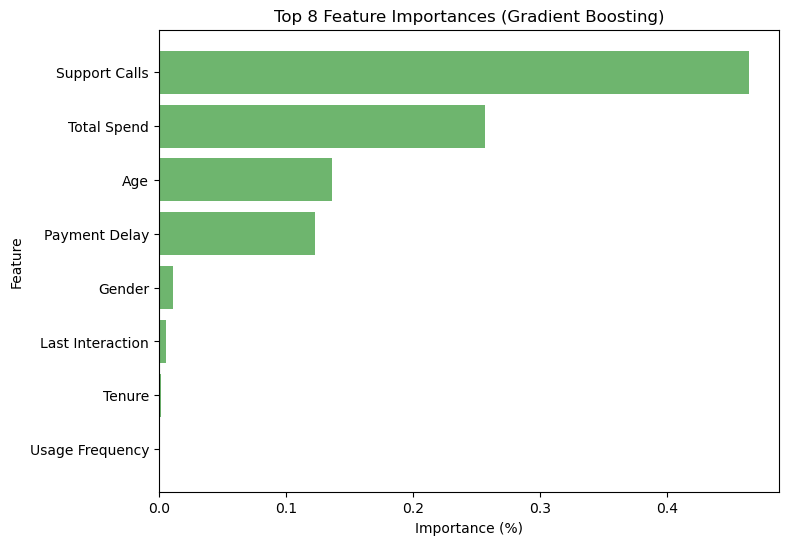

In [25]:
importances = gb.feature_importances_
features = X_train.columns

# Create dataframe and sort
feat_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Keep only top 10 features
top_feat_df = feat_df.head(8)

# Plot
plt.figure(figsize=(8,6))
plt.barh(top_feat_df["feature"], top_feat_df["importance"], color="#6eb56e")
plt.gca().invert_yaxis()
plt.xlabel("Importance (%)")
plt.ylabel("Feature")
plt.title("Top 8 Feature Importances (Gradient Boosting)")
plt.show()

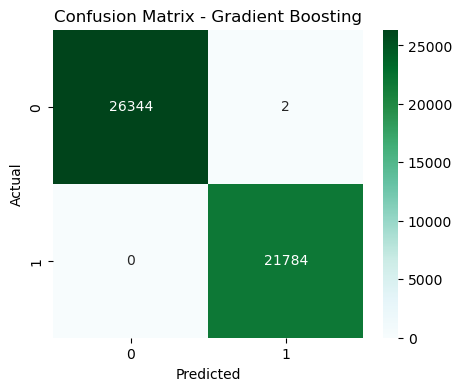

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="BuGn")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()